In [5]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

In [6]:
# Exercise 8.1 (forward-start)
def black_scholes_call(S, K, r, sigma, q, T):
    d1 = (np.log(S/K) + (r-q+0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    call = np.exp(-q*T)*S*norm.cdf(d1) - np.exp(-r*T)*K*norm.cdf(d2)

    return call

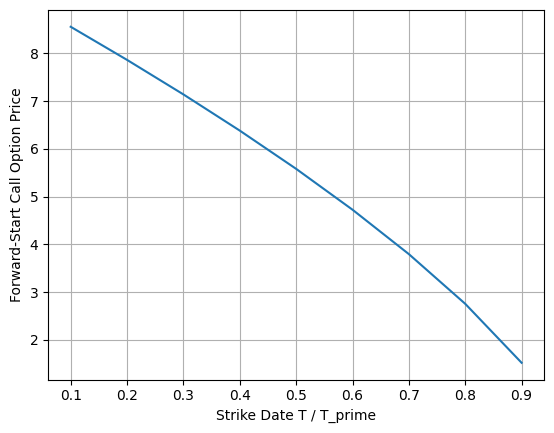

In [7]:
# Set parameters
S = 100
r = 0.05
sigma = 0.2
q = 0.02
T_prime = 1

T_values = np.linspace(0.1*T_prime, 0.9*T_prime, 9)
option_prices = []

for T in T_values:
    time_to_maturity = T_prime - T

    K = S * np.exp((r-q)*T)

    option_price = black_scholes_call(S, K, r, sigma, q, time_to_maturity)
    option_prices.append(option_price)

plt.plot(T_values, option_prices)
plt.xlabel('Strike Date T / T_prime')
plt.ylabel('Forward-Start Call Option Price')
plt.grid(True)
plt.show()

In [8]:
# Exercise 8.2 (call-on-call)
def call_on_call(S, r, sigma, q, T_prime):
    K_prime = S
    C = black_scholes_call(S, K_prime, r, sigma, q, T_prime)

    T = 0.5*T_prime
    K = C
    C_on_C = black_scholes_call(C, K, r, sigma, 0, T)

    return C, C_on_C

In [9]:
# Set parameters
S = 100
r = 0.05
sigma = 0.2
q = 0.02
T_prime = 1

C, C_on_C = call_on_call(S, r, sigma, q, T_prime)
print('Standard Call Value:', C)
print('Call-on-Call Value:', C_on_C)

# Now if S increased 10% instantaneously
S_prime = S*1.1

C_prime = black_scholes_call(S_prime, S, r, sigma, q, T_prime)
C_on_C_prime = black_scholes_call(C_prime, C_prime, r, sigma, 0, 0.5*T_prime)

# % Returns
call_return = ((C_prime - C)/C)*100
call_on_call_return = ((C_on_C_prime - C_on_C) / C_on_C) *100

print('If S raised 10% instantly:')
print('% Return for call option:', call_return)
print('% Reutrn for call-on-call option:', call_on_call_return)

Standard Call Value: 9.227005508154036
Call-on-Call Value: 0.6356233653043715
If S raised 10% instantly:
% Return for call option: 72.98456149673875
% Reutrn for call-on-call option: 72.98456149673889


In [10]:
# Exercise 8.3 (dividends, American)
def black_scholes_call_dividend(S, K, r, sigma, T, D, div_date):
    S_adj = S - np.exp(-r*div_date) * D
    d1 = (np.log(S_adj/K) + (r-q+0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    call = S_adj * norm.cdf(d1) - np.exp(-r*T)*K*norm.cdf(d2)

    return call

def american_call_dividend(S, K, r, sigma, T, D, div_date, steps):
    dt = T / steps
    u = np.exp(sigma*np.sqrt(dt))
    d = 1/u
    p = (np.exp(r*dt) - d) / (u - d)

    stock_tree = np.zeros((steps+1, steps+1))
    stock_tree[0,0] = S

    for i in range(1, steps+1):
        for j in range(i+1):
            # Calculate each step in tree
            stock_tree[j,i] = S * (u**j) * (d**(i-j))

            # Pay dividend if applicable
            if i == int(div_date / dt):
                stock_tree[j,i] -= D
    
    option_tree = np.maximum(stock_tree[:, steps] - K, 0)

    # Backward induction for pricing
    for i in range(steps-1, -1, -1):
        for j in range(i+1):
            hold = np.exp(-r*dt)*(p*option_tree[j+1] + (1-p)*option_tree[j])
            exercise = stock_tree[j,i] - K
            option_tree[j] = max(hold, exercise)

    return option_tree[0]

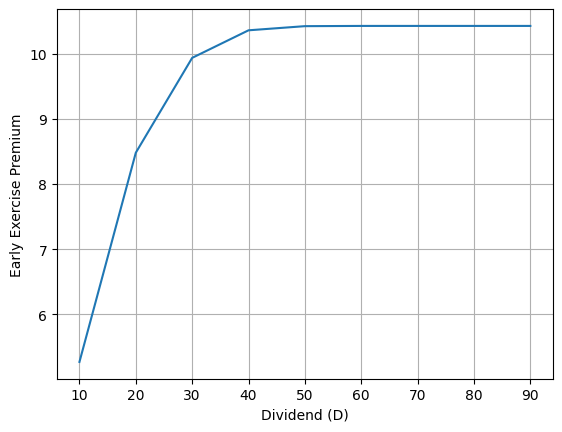

In [11]:
# Set parameters
S = 100
r = 0.05
sigma = 0.2
T_prime = 1
K = S
div_date = 0.5*T_prime
steps = 100


dividend_values = np.linspace(0.1*S, 0.9*S, 9)
early_exercise_premium = []

for D in dividend_values:
    american_call_price = american_call_dividend(S, K, r, sigma, T_prime, D, div_date, steps)

    european_call_price = black_scholes_call_dividend(S, K, r, sigma, T_prime, D, div_date)

    premium = american_call_price - european_call_price
    early_exercise_premium.append(premium)


plt.plot(dividend_values, early_exercise_premium)
plt.xlabel('Dividend (D)')
plt.ylabel('Early Exercise Premium')
plt.grid(True)
plt.show()


In [12]:
# Exercise 8.4 (chooser)

# Can use black_scholes_call from above

def black_scholes_put(S, k, r, sigma, T):
    d1 = (np.log(S/K) + (r+0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    put = K * np.exp(-r*T) *norm.cdf(-d2) - S * norm.cdf(-d1)

    return put

def chooser_option(S, K, r, sigma, T_chooser, T_maturity):
    S_star = K * np.exp(-r* (T_maturity - T_chooser))

    call = black_scholes_call(S, K, r, sigma, 0, T_maturity)
    put = black_scholes_put(S, K, r, sigma, T_maturity)

    chooser_price = call + put - S_star

    return chooser_price

In [13]:
# Set parameters
S = 100
K = 100
r = 0.05
sigma = 0.2
T_chooser = 0.5
T_maturity = 1

chooser_price = chooser_option(S, K, r, sigma, T_chooser, T_maturity)
print('Simple Chooser Value:', chooser_price)

Simple Chooser Value: -81.50688160839073


In [14]:
# Exercise 8.5 (chooser vs straddle)
def chooser_vs_straddle(S, r, sigma, T_prime):
    K = S
    T_chooser = 0.5*T_prime

    chooser_cost = chooser_option(S, K, r, sigma, T_chooser, T_prime)

    call_cost = black_scholes_call(S, K, r, sigma, 0, T_prime)
    put_cost = black_scholes_put(S, K, r, sigma, T_prime)
    straddle_cost = call_cost + put_cost

    difference = chooser_cost - straddle_cost

    print('Chooser Option Cost:', chooser_cost)
    print('Straddle Cost (Call + Put):', straddle_cost)
    print('Difference (Chooser - Straddle):', difference)

    return chooser_cost, straddle_cost, difference

In [15]:
# Set parameters
S = 100
r = 0.05
sigma = 0.2
T_prime = 1

chooser, straddle, difference = chooser_vs_straddle(S, r, sigma, T_prime)

Chooser Option Cost: -81.50688160839073
Straddle Cost (Call + Put): 16.024109594442535
Difference (Chooser - Straddle): -97.53099120283326


In [16]:
# Exercise 8.6 (lookback option)

## Lookback call price = S(1 - (sigma*sqrt(T))/2) - K*exp(-r*T)
## Minimum fee = S(1 - (sigma*sqrt(T))/2) - S*exp(-r*T)

# Set parameters
S = 100
r = 0.05
sigma = 0.2
T = 2/12 # 2 months

minimum_fee = S * (1 - (sigma*np.sqrt(T))/2) - S*np.exp(-r*T)
print(minimum_fee)

-3.252612168526227


In [35]:
# Exercise 8.7 (down-and-out)
def simulate_asset_price(S, r, sigma, q, T, simulations=500):
    '''  
    Simulate asset prices at T
    '''
    try:
        drift = (r - q - 0.5*sigma**2)*T
        shock = sigma * np.sqrt(T) * np.random.randn(int(simulations))
        prices = S * np.exp(drift + shock)
        print('End prices head:', prices[:5])
        return prices
    except Exception as e:
        print('Error in simulate_asset_price:', e)

def hedge_cost_european_call(S, K, r, sigma, T, end_prices):
    '''  
    Cost calculated for hedging European call
    '''
    try:
        call_payoff = np.maximum(end_prices - K, 0)
        call_cost = black_scholes_call(S, K, r, sigma, 0, T)
        costs = np.maximum(end_prices - call_payoff, 0) - call_cost
        print('Euro call costs head:', costs[:5])
        return costs
    except Exception as e:
        print('Error in hedge_cost_european_call:', e)

def hedge_cost_down_and_out_call(S, K, r, sigma, T, barrier, end_prices, simulations=500):
    '''  
    Cost calculated for heding down-and-out call
    '''
    try:
        knock_out_path = simulate_asset_price(S, r, sigma, q, T, simulations)
        knock_out = np.any(knock_out_path < barrier)

        down_out_call_payoff = np.where(knock_out, 0, np.maximum(end_prices - K, 0))

        call_cost = black_scholes_call(S, K, r, sigma, 0, T)
        costs = np.maximum(end_prices - down_out_call_payoff, 0) - call_cost
        print('Down-and-out costs head:', costs[:5])
        return costs
    except Exception as e:
        print('Error in hedge_cost_down_and_out_call:', e)

def compare_hedges(S, r, q, simulations=500):
    '''  
    Perform simuations and create histograms for hedges
    '''
    T = 1
    K = S
    barrier = S*0.9

    end_prices = simulate_asset_price(S, r, sigma, q, T, simulations)
    print('End prices head:', end_prices[:5])

    costs_european_call = hedge_cost_european_call(S, K, r, sigma, T, end_prices)
    costs_down_and_out_call = hedge_cost_down_and_out_call(S, K, r, sigma, T, barrier, end_prices, simulations)

    print('Euro call costs head:', costs_european_call[:5])
    print('Down-and-out costs head:', costs_down_and_out_call[:5])

    plt.clf()
    plt.figure(figsize=(14,6))
    plt.hist(costs_european_call, bins=30, alpha=0.5, label='European Call Hedge')
    plt.hist(costs_down_and_out_call, bins=30, alpha=0.5, label='Down-and-Out Call Hedge')
    plt.xlabel('End-of-Year Cost')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

In [36]:
# Set parameters
S = 100
r = 0.05
sigma = 0.2
q = 0.02

prices = simulate_asset_price(S, r, sigma, q, T, simulations=500)
costs = hedge_cost_european_call(S, K, r, sigma, T, prices)
do_costs = hedge_cost_down_and_out_call(S, K, r, sigma, T, barrier=S*0.9, end_prices=prices, simulations=500)

End prices head: [ 92.46597172 104.48056762 100.30713465 109.16795567 111.63077604]
Euro call costs head: [88.79123687 96.32526515 96.32526515 96.32526515 96.32526515]
End prices head: [112.54081156  98.38470911 101.03749678  93.72778276 105.63082465]
Down-and-out costs head: [ 88.79123687 100.80583277  96.6323998  105.49322082 107.95604119]


End prices head: [124.34067559  83.44122456  86.56500555 101.25347781  95.03066406]
End prices head: [124.34067559  83.44122456  86.56500555 101.25347781  95.03066406]
Euro call costs head: [89.54941643 72.99064099 76.11442198 89.54941643 84.58008049]
End prices head: [100.99779922  88.12055544 128.0833483   84.49913062 100.55732615]
Down-and-out costs head: [113.89009202  72.99064099  76.11442198  90.80289424  84.58008049]
Euro call costs head: [89.54941643 72.99064099 76.11442198 89.54941643 84.58008049]
Down-and-out costs head: [113.89009202  72.99064099  76.11442198  90.80289424  84.58008049]


<Figure size 640x480 with 0 Axes>

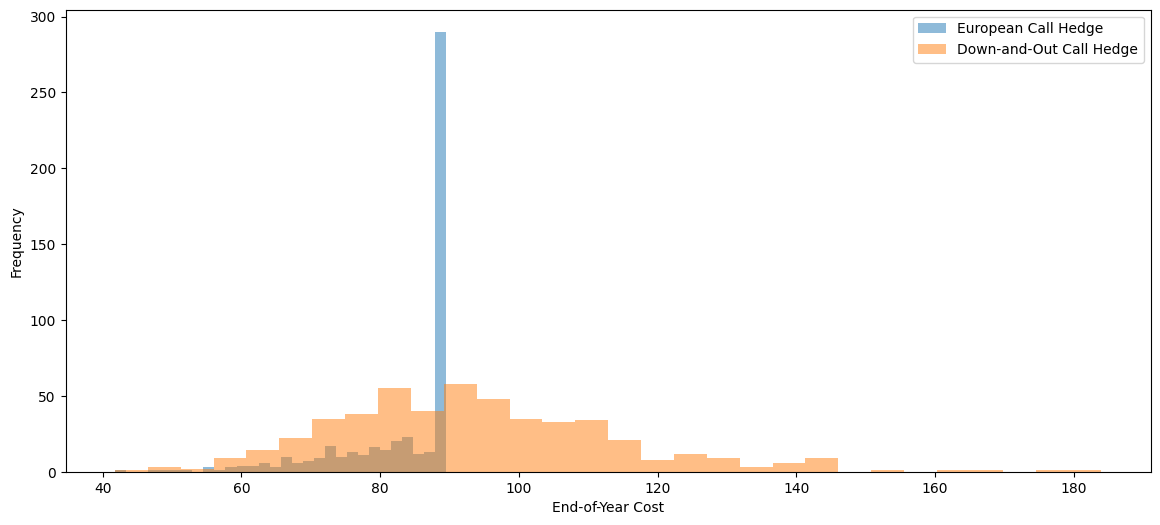

: 

In [37]:
compare_hedges(S, r, q, simulations=500)